# **Tarea 2 2026**

Constanza Luarte Salazar
2022428147


### 1.1 Carga de Bibliotecas y base de datos 

In [1]:
import pandas as pd
import numpy as np
import numpy.linalg as la
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import linearmodels.panel as lmp
import warnings
warnings.filterwarnings('ignore')

# Configuración estética global
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
df = pd.read_csv('dataset_prueba.csv', delimiter=",", decimal='.')
df.head()

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


### 1.2 Inspección de Datos y Valores Nulos


In [2]:
print(f'─── Dimensiones del DataFrame  ───')
print(f' {df.shape}\n')

print("\n─── Tipos de datos ───")
print(df.dtypes.to_string())

print("\n─── Nulos por columna ─────")
print(df.isnull().sum())

print("\n─── Categorías por columna ─────")
for col in df.select_dtypes(include='object').columns:
    print(f"Categorias en {col}: {df[col].unique()}")

─── Dimensiones del DataFrame  ───
 (12040, 41)


─── Tipos de datos ───
iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float

### 1.3 Distribuciones y detección de outliers 


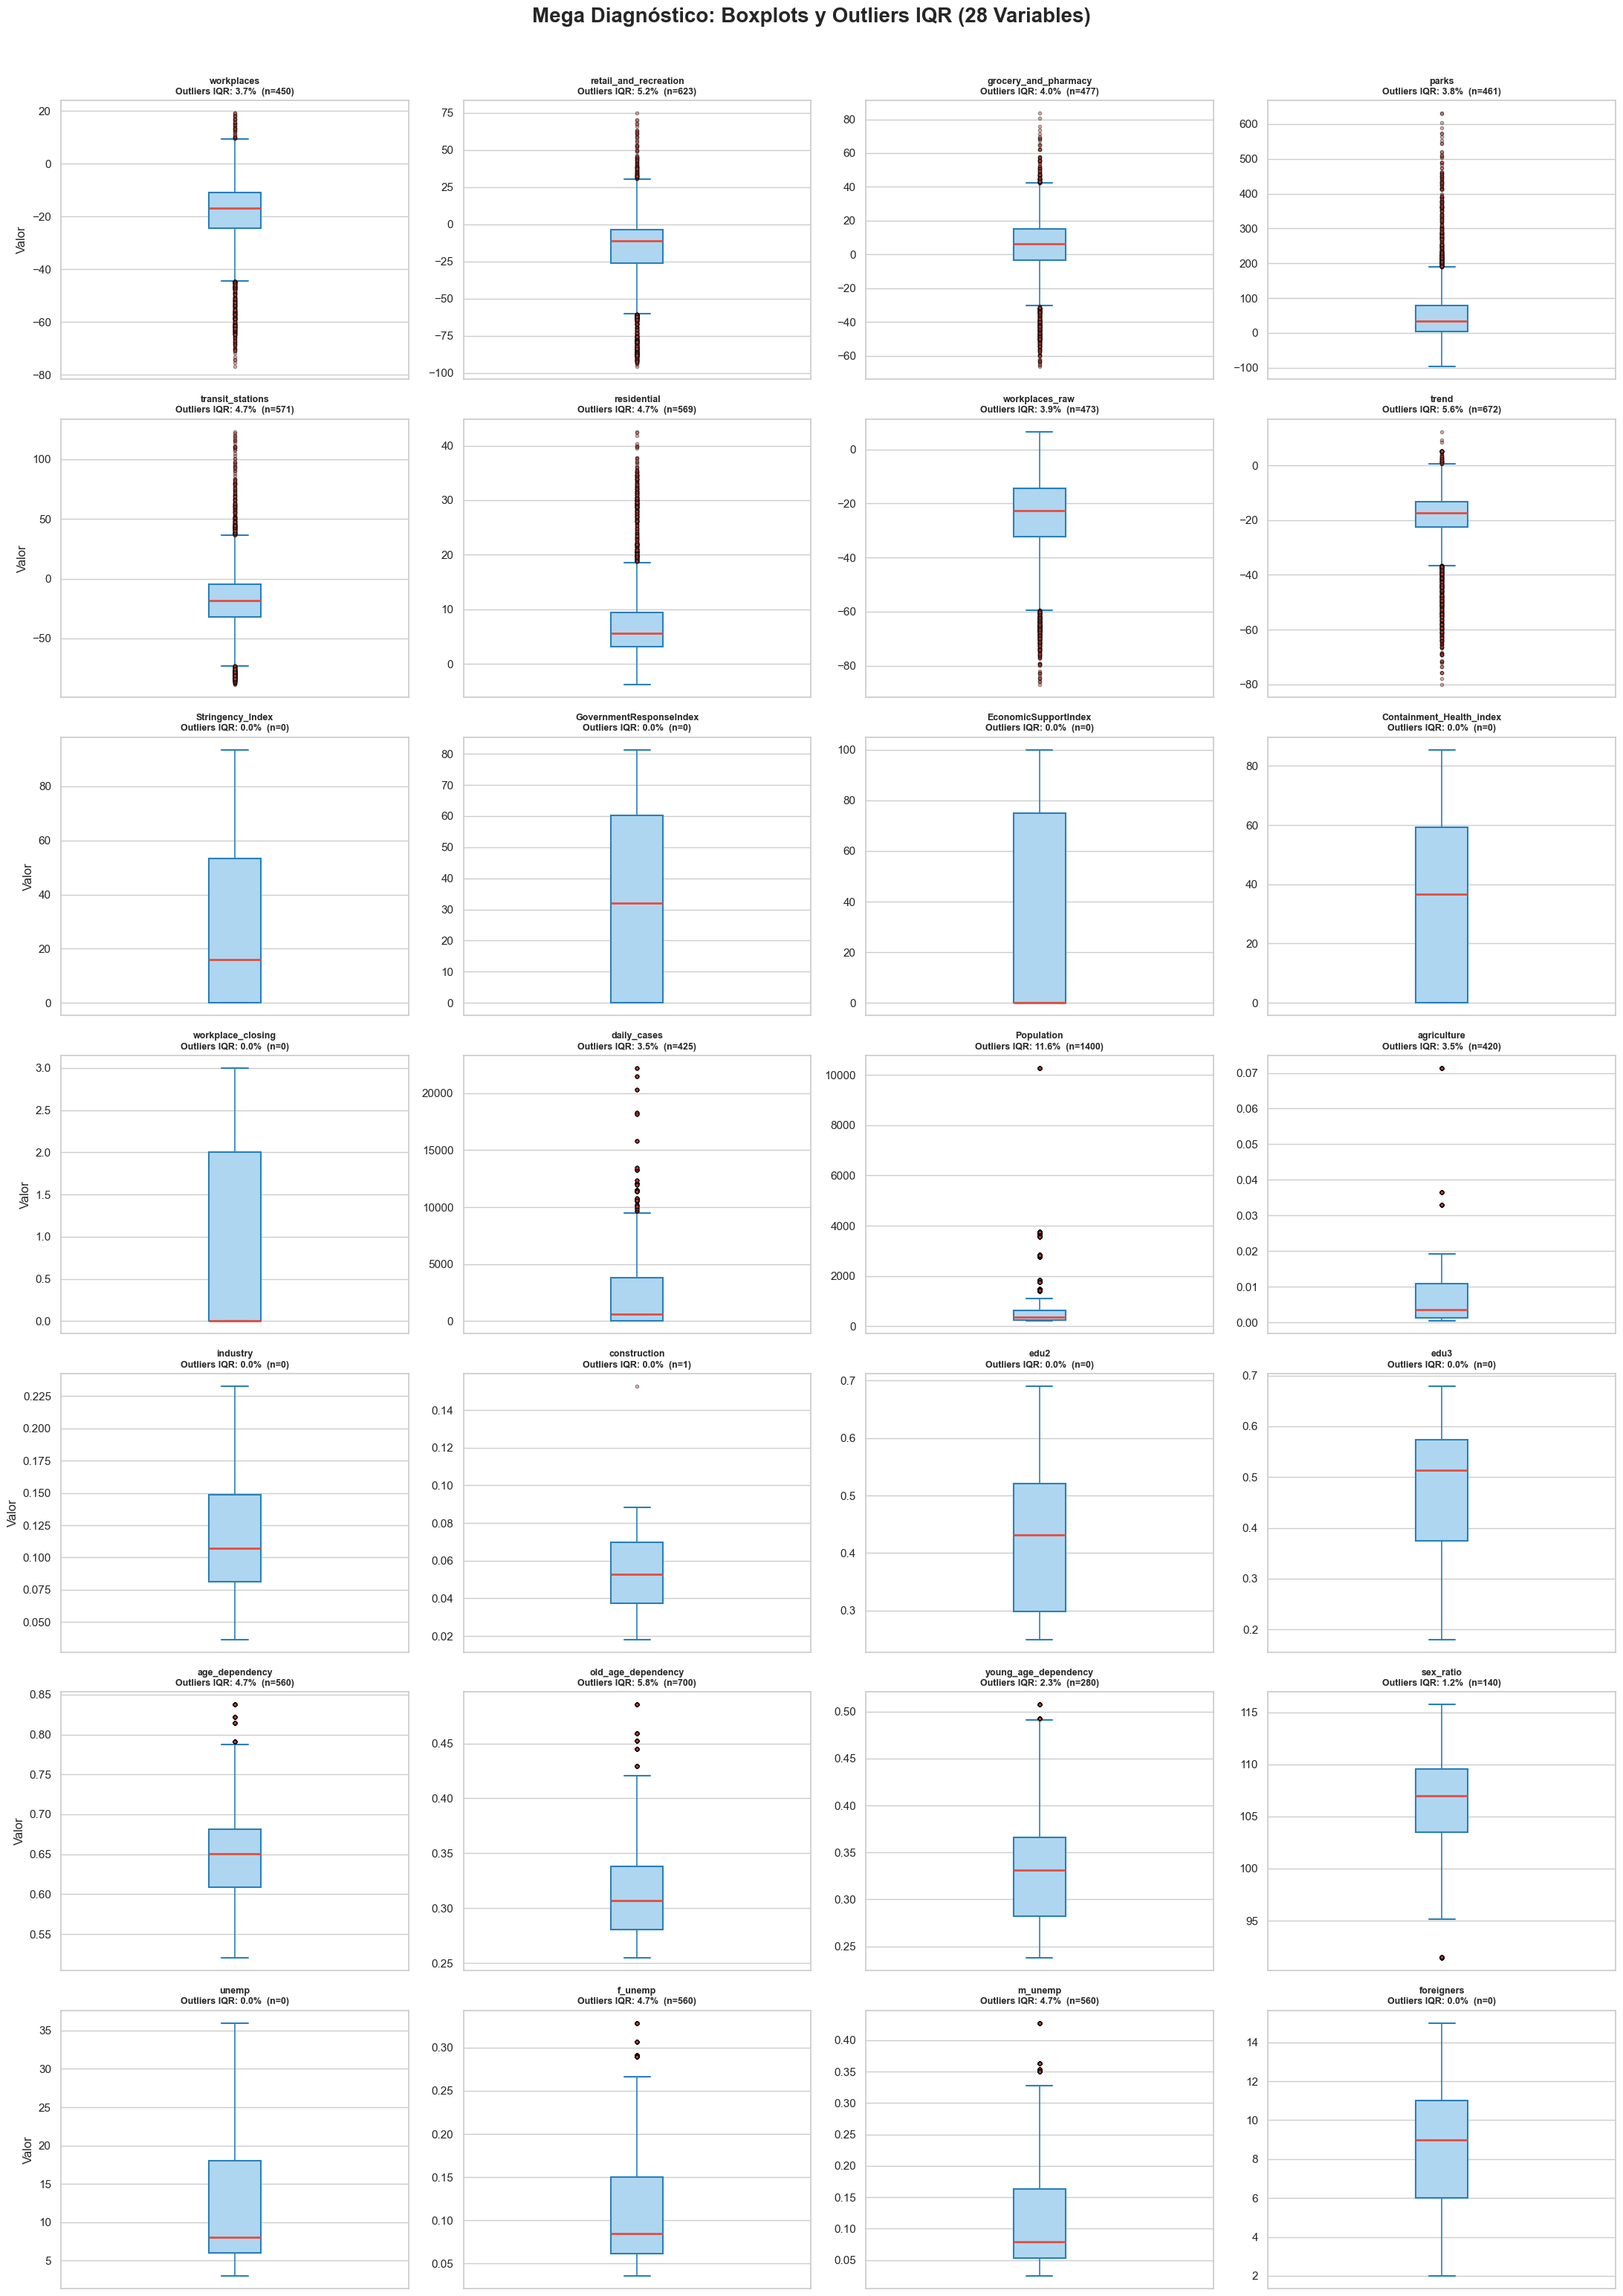

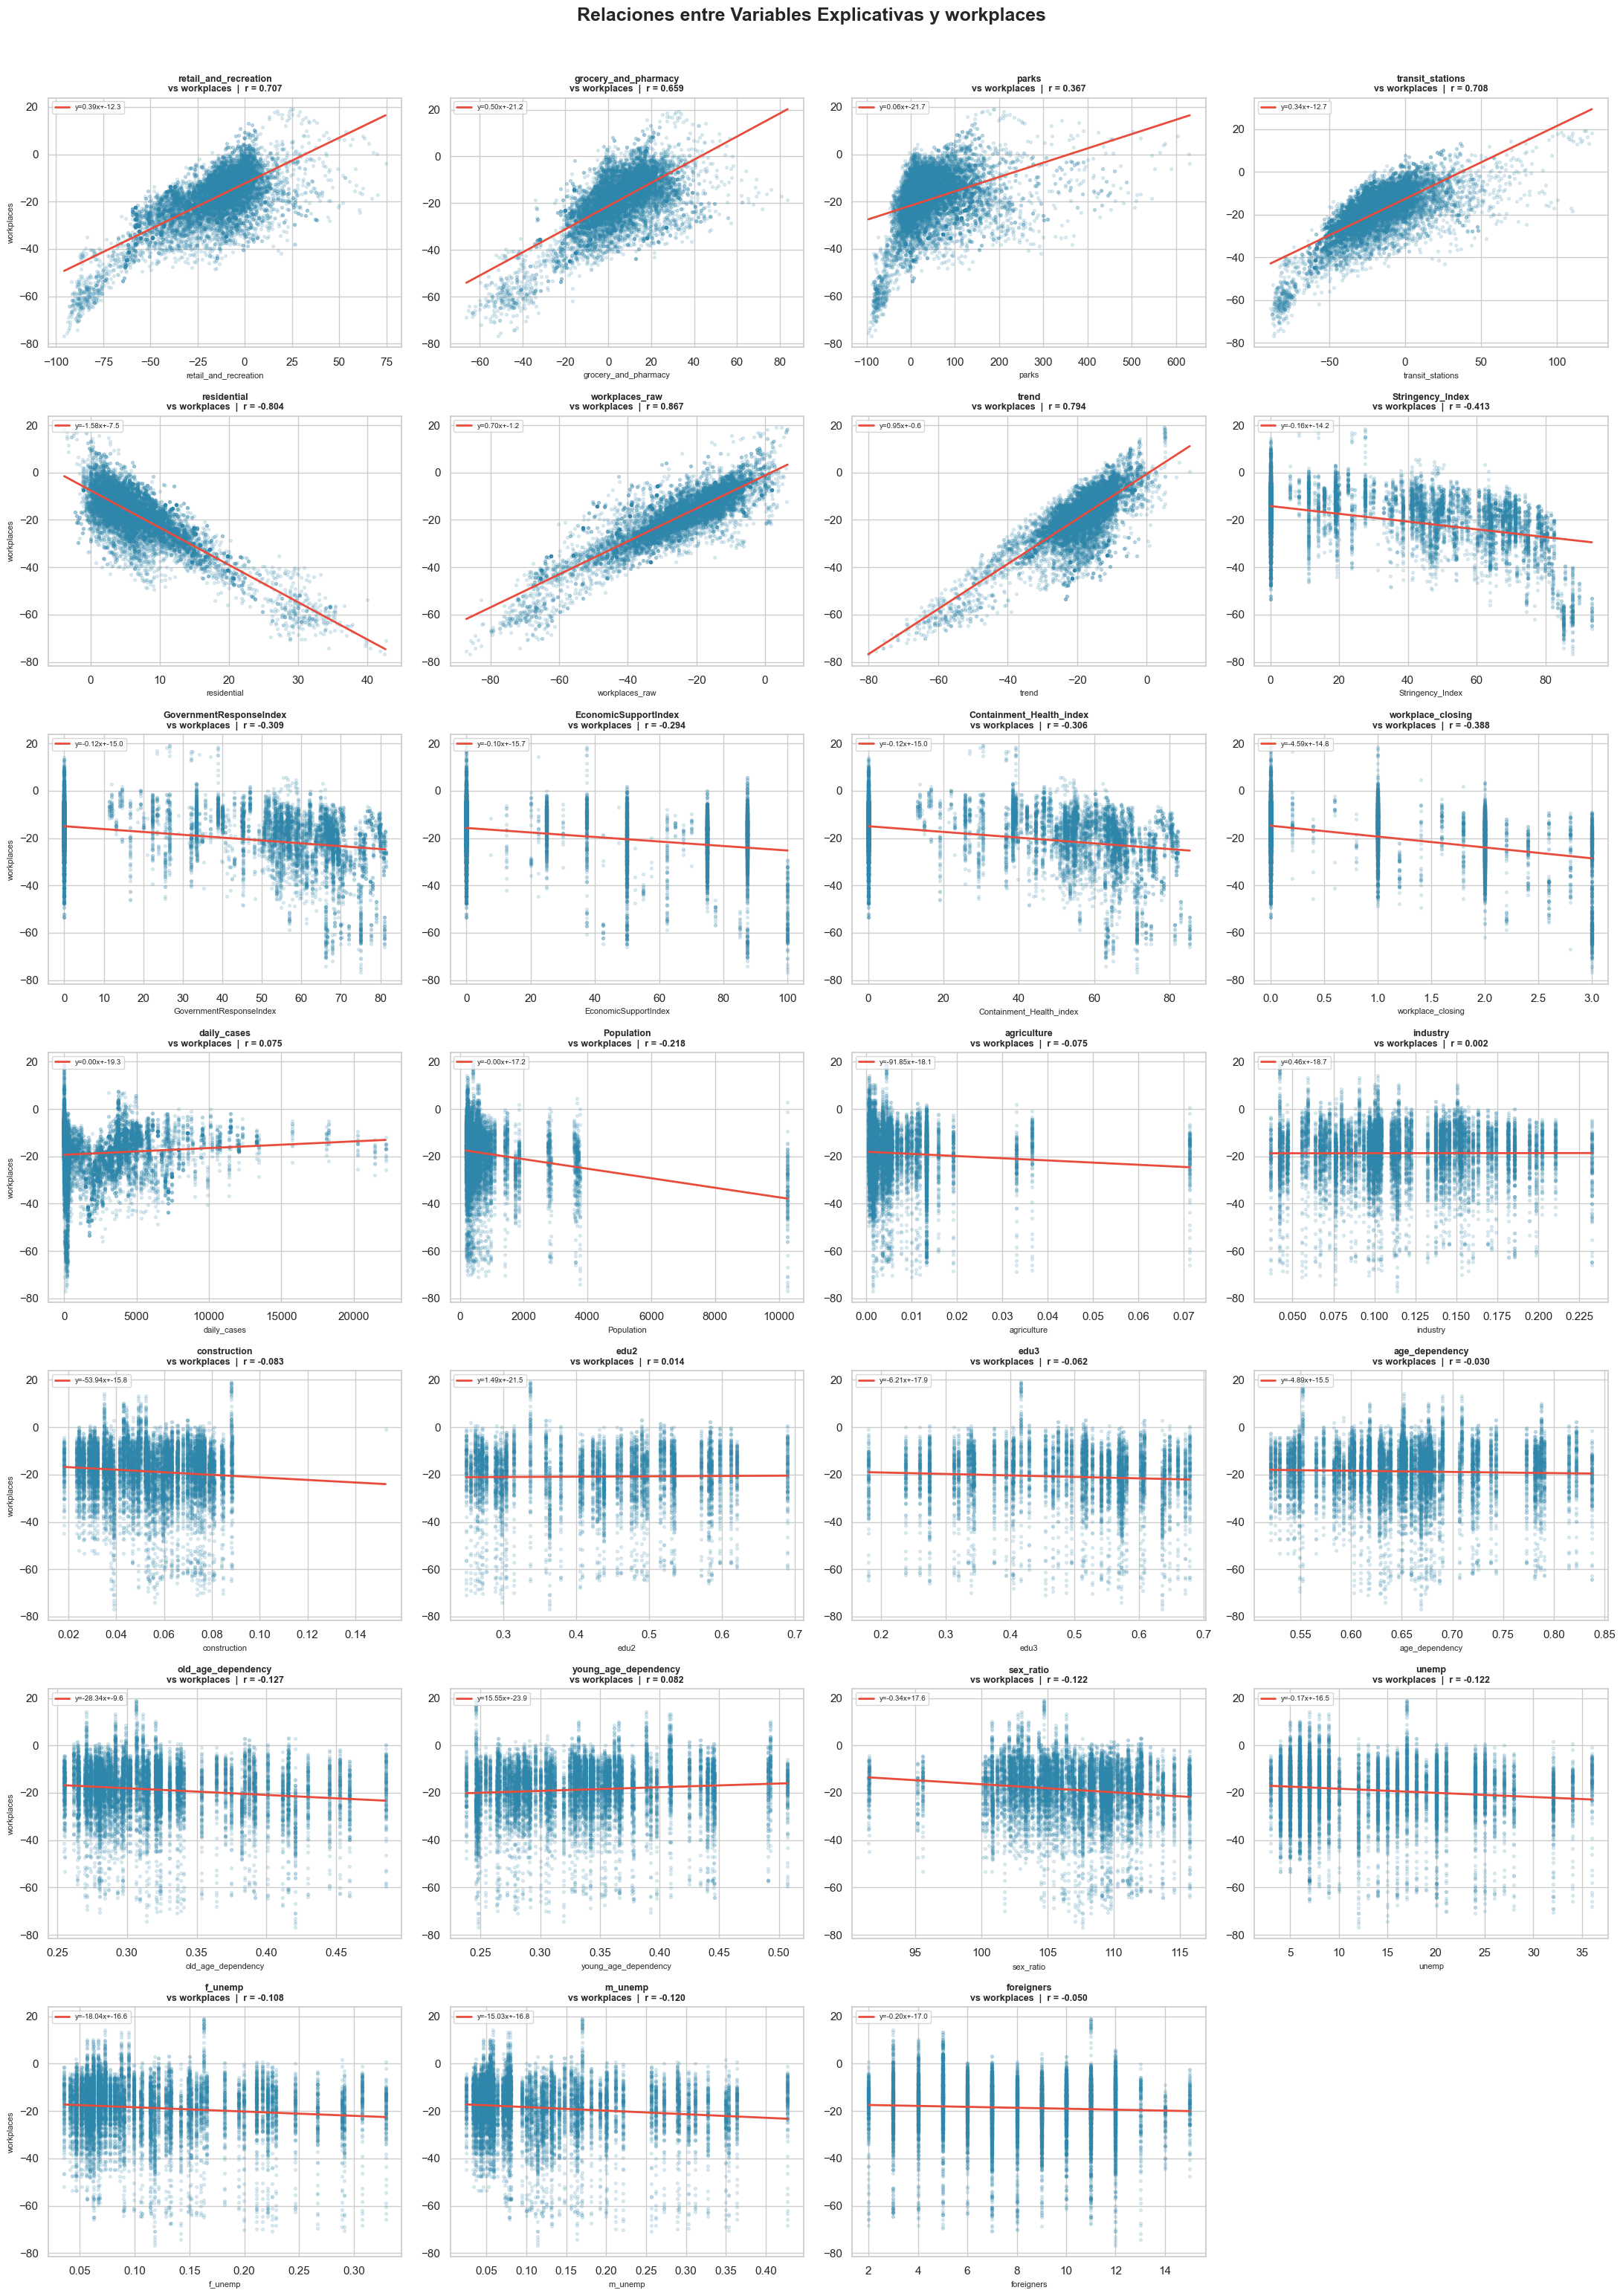

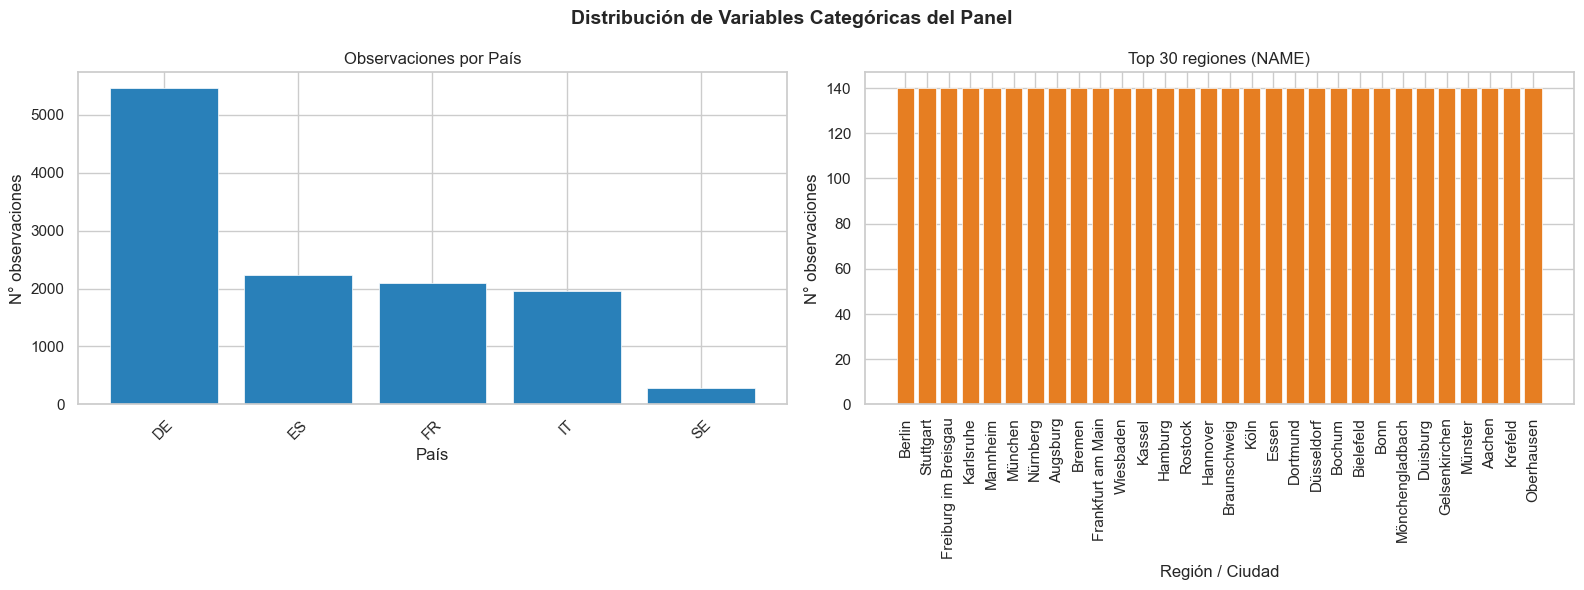

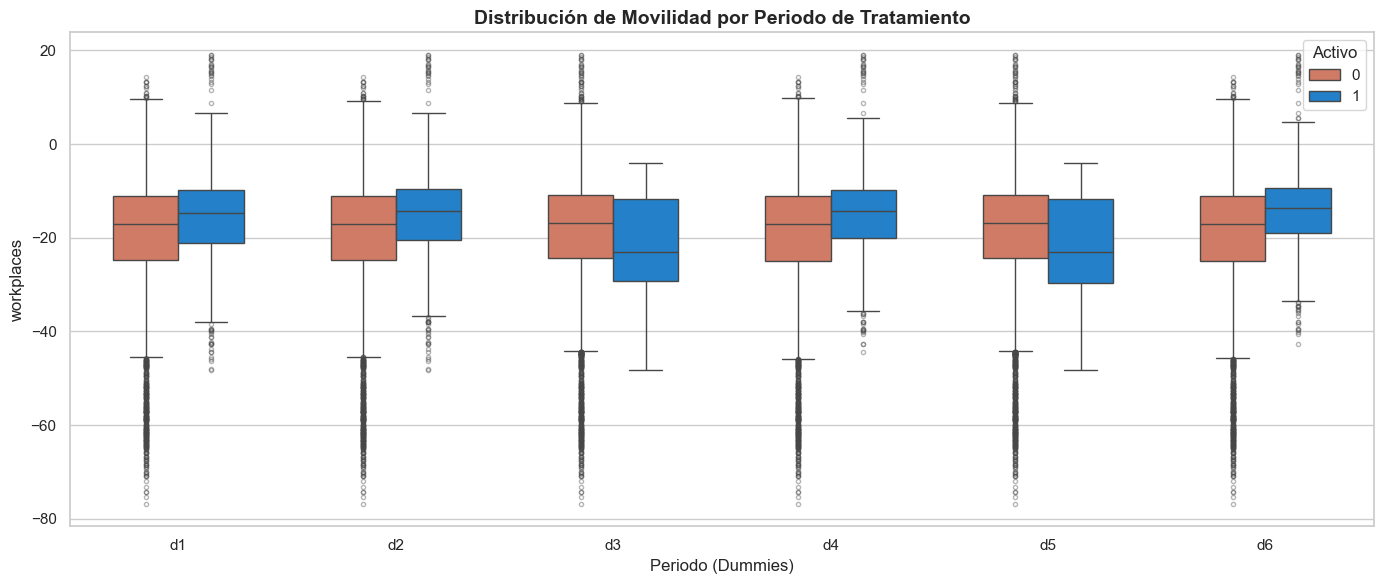

In [3]:
# Función lambda para limpiar nombres
sn = lambda c: c.replace('_percent_change_from_baseline', '').replace('Valor_', '')

# Definir el Target
target = 'workplaces'

# 1. CENTRALIZACIÓN DE VARIABLES
# Incluimos absolutamente todas las continuas e índices (sin fechas, dummies ni strings)
num_vars = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline',
    'parks_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline', 'workplaces_raw', 'trend',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex', 
    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index', 'workplace_closing',
    'daily_cases', 'Population', 'agriculture', 'industry', 'construction', 
    'edu2', 'edu3', 'age_dependency', 'old_age_dependency', 'young_age_dependency', 
    'sex_ratio', 'unemp', 'f_unemp', 'm_unemp', 'foreigners'
]

# vars_plot incluye el target (para boxplot), vars_rel lo excluye (para scatter)
vars_plot = [target] + num_vars
vars_rel  = num_vars  

# Parámetros generales
ncols = 4


# ── 1.3.a BOXPLOTS ──────────────────────────────────────────────────────
nrows_box = int(np.ceil(len(vars_plot) / ncols))
fig, axes = plt.subplots(nrows_box, ncols, figsize=(22, nrows_box * 4.5))
axes = axes.flatten()

# OPTIMIZACIÓN: Diccionarios de estilo definidos fuera del bucle
box_props = dict(facecolor='#AED6F1', color='#2980B9', linewidth=1.5)
med_props = dict(color='#E74C3C', linewidth=2)
whk_props = dict(color='#2980B9', linewidth=1.2)
cap_props = dict(color='#2980B9', linewidth=1.5)
fli_props = dict(marker='o', color='#E74C3C', alpha=0.4, markerfacecolor='#E74C3C', markersize=3)

for i, col in enumerate(vars_plot):
    ax = axes[i]
    data = df[col].dropna()
    
    if not data.empty:
        ax.boxplot(data, vert=True, patch_artist=True, boxprops=box_props,
                   medianprops=med_props, whiskerprops=whk_props,
                   capprops=cap_props, flierprops=fli_props)
        
        q1, q3 = data.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
        pct_out = (n_out / len(data)) * 100
    else:
        n_out, pct_out = 0, 0
        
    ax.set_title(f"{sn(col)}\nOutliers IQR: {pct_out:.1f}%  (n={n_out})", fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel("Valor" if i % ncols == 0 else "")

for j in range(len(vars_plot), len(axes)): axes[j].set_visible(False)
fig.suptitle(f"Mega Diagnóstico: Boxplots y Outliers IQR ({len(vars_plot)} Variables)", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()


# ── 1.3.b SCATTER + CORRELACIÓN ─────────────────────────────────────────
nrows_rel = int(np.ceil(len(vars_rel) / ncols))
fig, axes = plt.subplots(nrows_rel, ncols, figsize=(22, nrows_rel * 4.5))
axes = axes.flatten()

for i, col in enumerate(vars_rel):
    ax = axes[i]
    sub = df[[target, col]].dropna()
    
    if not sub.empty:
        ax.scatter(sub[col], sub[target], alpha=0.15, s=8, color='#2E86AB', rasterized=True)
        r = sub[col].corr(sub[target])
        
        # OPTIMIZACIÓN: Validar si hay variabilidad antes de hacer polyfit para evitar errores de Matriz Singular
        if len(sub) > 2 and sub[col].nunique() > 1:
            m, b = np.polyfit(sub[col], sub[target], 1)
            x0, x1 = sub[col].min(), sub[col].max()
            ax.plot([x0, x1], [m*x0+b, m*x1+b], color='#E74C3C', linewidth=2, label=f'y={m:.2f}x+{b:.1f}')
            ax.legend(fontsize=7, loc='upper left')
    else:
        r = 0.0

    label = sn(col)
    ax.set_title(f"{label}\nvs {target}  |  r = {r:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(target if i % ncols == 0 else "", fontsize=8)

for j in range(len(vars_rel), len(axes)): axes[j].set_visible(False)
fig.suptitle(f"Relaciones entre Variables Explicativas y {target}", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()


# ── 1.3.d VARIABLES CATEGÓRICAS ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de Variables Categóricas del Panel', fontsize=14, fontweight='bold')

# OPTIMIZACIÓN: value_counts() es C++ por debajo, mucho más rápido que groupby().count()
obs_c = df['country'].value_counts()
axes[0].bar(obs_c.index, obs_c.values, color='#2980B9', edgecolor='white', linewidth=0.5)
axes[0].set(title='Observaciones por País', xlabel='País', ylabel='N° observaciones')
axes[0].tick_params(axis='x', rotation=45)

obs_n = df['NAME'].value_counts().head(30)
axes[1].bar(obs_n.index, obs_n.values, color='#E67E22', edgecolor='white', linewidth=0.5)
axes[1].set(title='Top 30 regiones (NAME)', xlabel='Región / Ciudad', ylabel='N° observaciones')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout(); plt.show()


# ── 1.3.e DUMMIES DE TRATAMIENTO ────────────────────────────────────────
dummy_cols = [c for c in ['d1','d2','d3','d4','d5','d6'] if c in df.columns]

if dummy_cols:
    # OPTIMIZACIÓN: Seleccionar SOLO las columnas necesarias antes de hacer melt ahorra muchísima memoria RAM
    cols_to_melt = [target] + dummy_cols
    df_m = df[cols_to_melt].dropna(subset=[target]).melt(
        id_vars=[target], value_vars=dummy_cols, 
        var_name='Periodo', value_name='Activo'
    )
    
    # Asegurarse que "Activo" se trate como categoría numérica
    df_m['Activo'] = df_m['Activo'].astype(int)

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_m, x='Periodo', y=target, hue='Activo',
                palette=["#e17055","#0984e3"], width=0.6,
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
    
    plt.title('Distribución de Movilidad por Periodo de Tratamiento', fontsize=14, fontweight='bold')
    plt.xlabel('Periodo (Dummies)')
    plt.ylabel(target)
    plt.tight_layout(); plt.show()
else:
    print("⚠️ No se encontraron columnas dummy (d1–d6).")

### 1.4 Matriz de Correlación Gigante


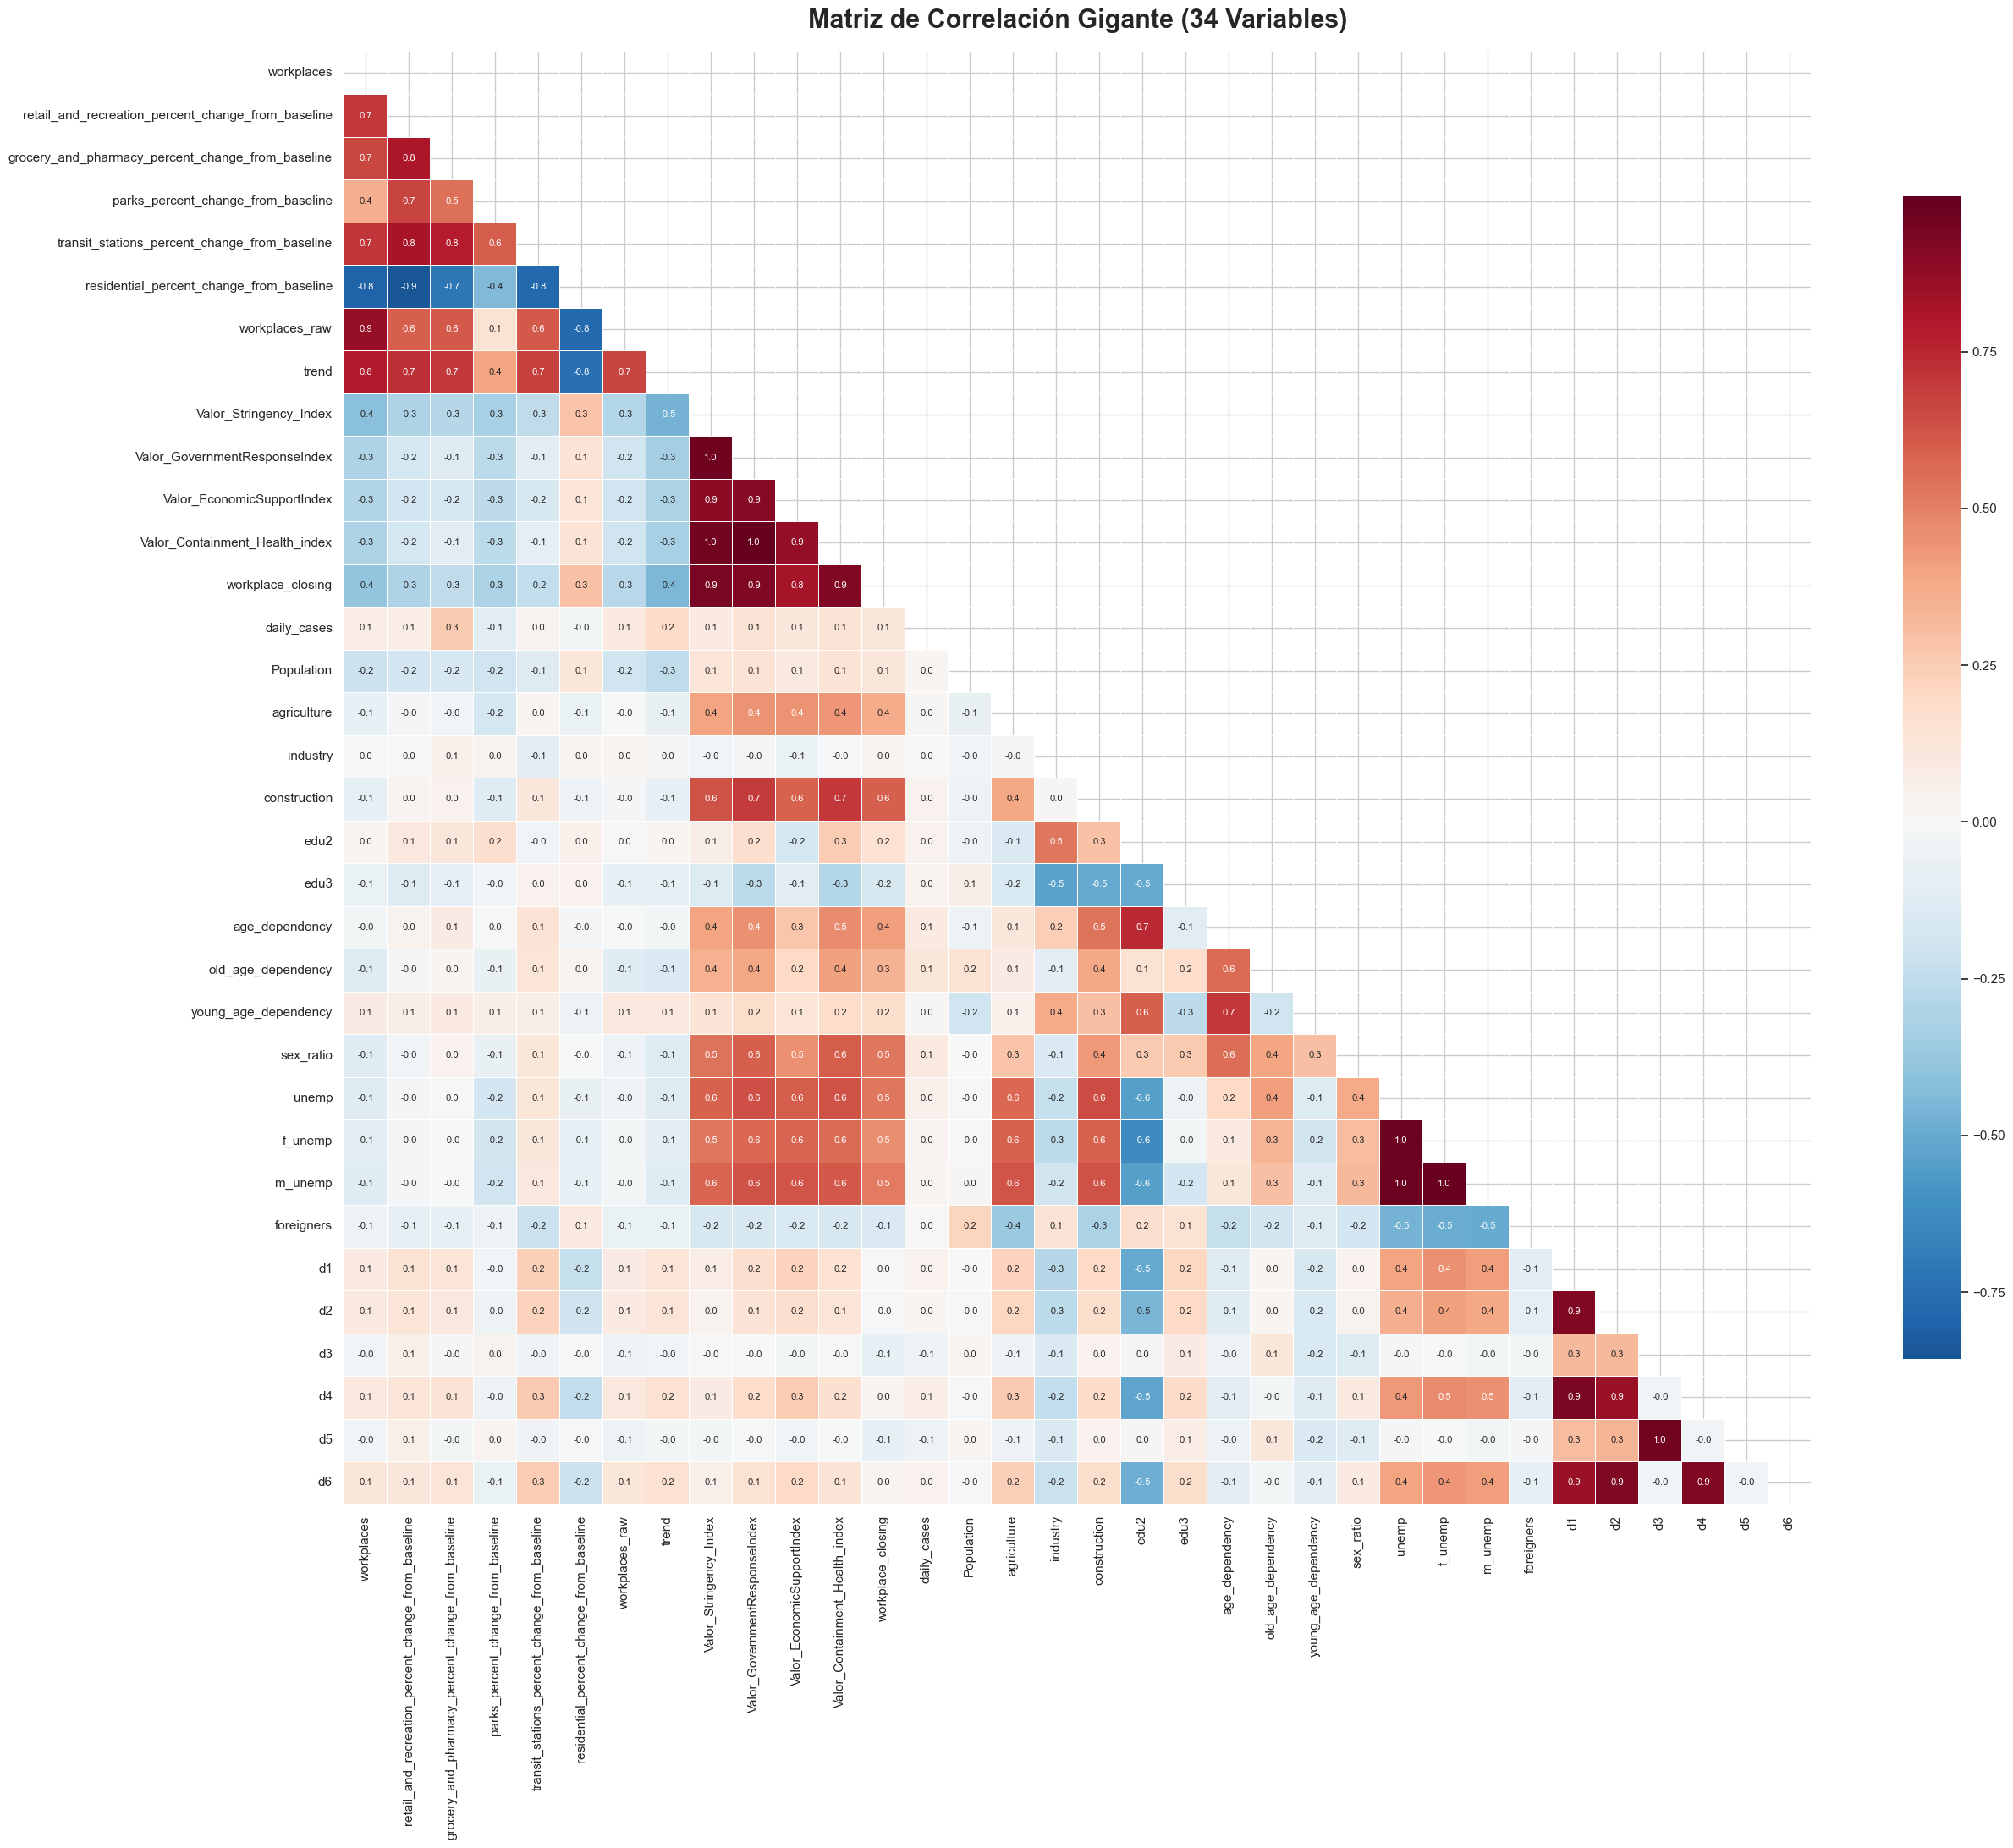

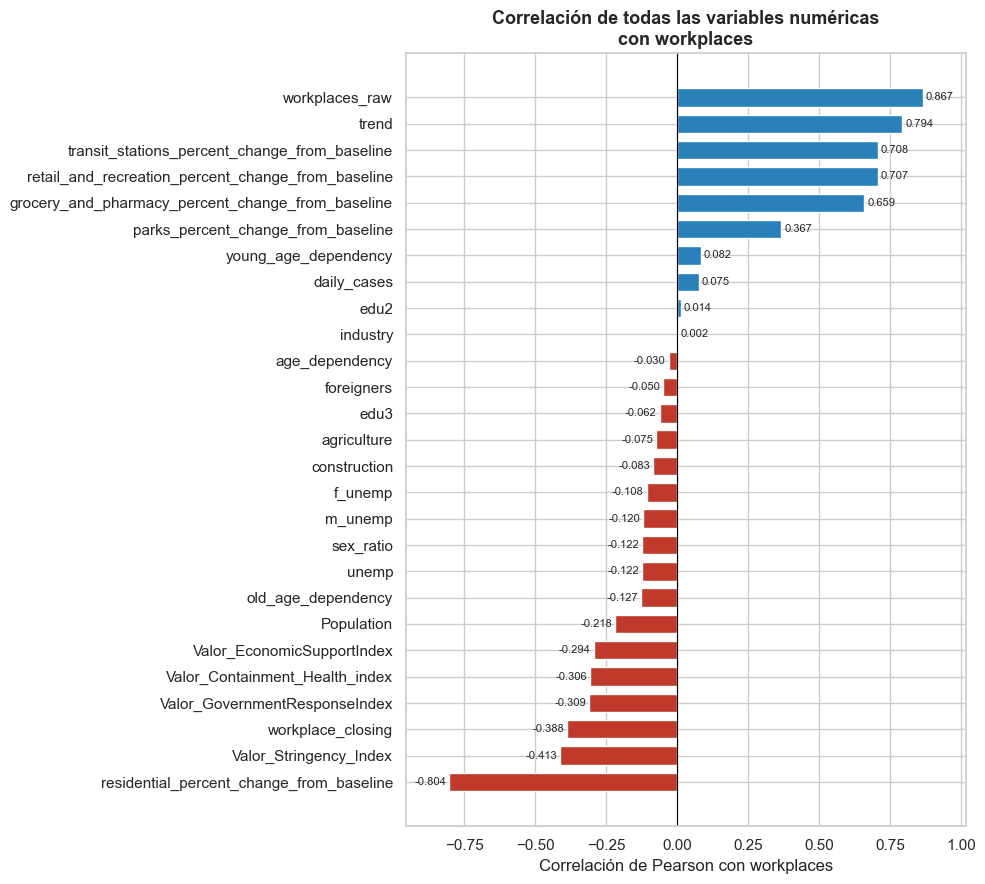


Listado completo de correlaciones (|r|) con workplaces (33 variables):
workplaces_raw                                        0.8667
residential_percent_change_from_baseline              0.8042
trend                                                 0.7940
transit_stations_percent_change_from_baseline         0.7083
retail_and_recreation_percent_change_from_baseline    0.7066
grocery_and_pharmacy_percent_change_from_baseline     0.6591
Valor_Stringency_Index                                0.4135
workplace_closing                                     0.3879
parks_percent_change_from_baseline                    0.3673
Valor_GovernmentResponseIndex                         0.3088
Valor_Containment_Health_index                        0.3056
Valor_EconomicSupportIndex                            0.2936
Population                                            0.2179
old_age_dependency                                    0.1267
unemp                                                 0.1224
sex_ratio    

In [4]:
# Matriz de 34 variables (28 continuas + 6 dummies)
corr_cols = vars_plot + dummy_cols

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(26, 22))
sns.heatmap(corr, mask=mask, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=0.4, cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Matriz de Correlación Gigante (34 Variables)", 
             fontsize=22, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# ── 1.3.c CORRELACIONES CON WORKPLACES ──────────────────────────────────
corr_wp = df[vars_plot].corr()['workplaces'].drop('workplaces').sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(corr_wp.index, corr_wp.values,
               color=['#C0392B' if v<0 else '#2980B9' for v in corr_wp.values],
               edgecolor='white', height=0.7)
for bar, val in zip(bars, corr_wp.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con workplaces", fontsize=12)
ax.set_title("Correlación de todas las variables numéricas\ncon workplaces", fontsize=13, fontweight='bold')
ax.set_xlim(corr_wp.min()-0.15, corr_wp.max()+0.15)
plt.tight_layout(); plt.show()

# Calculamos todas las correlaciones, eliminamos la autoreferencia y ordenamos
all_corr = corr["workplaces"].drop("workplaces").abs().sort_values(ascending=False)

print(f"\nListado completo de correlaciones (|r|) con workplaces ({len(all_corr)} variables):")
print(all_corr.round(4).to_string())




### 1.6 Diagnóstico de Multicolinealidad (VIF)

In [5]:
vif_clean_cols = ['Valor_Stringency_Index', 'daily_cases', 'Population', 
                    'agriculture', 'industry','construction',
                    'old_age_dependency', 
                   'sex_ratio', 'foreigners',
                   'unemp']

df_vif_clean = df[vif_clean_cols].dropna()
X_vif_clean = sm.add_constant(df_vif_clean)
vif_data_clean = pd.DataFrame()
vif_data_clean["Variable"] = X_vif_clean.columns
vif_data_clean["VIF_Limpio"] = [variance_inflation_factor(X_vif_clean.values, i) for i in range(len(X_vif_clean.columns))]

print("────── VIF MODELO DEFINITIVO  ──────")
print(vif_data_clean[vif_data_clean['Variable'] != 'const'].sort_values(by="VIF_Limpio", ascending=False).round(2).to_string(index=False))

────── VIF MODELO DEFINITIVO  ──────
              Variable  VIF_Limpio
                 unemp        3.03
Valor_Stringency_Index        2.29
          construction        2.25
           agriculture        1.68
             sex_ratio        1.59
    old_age_dependency        1.47
            foreigners        1.43
              industry        1.17
            Population        1.14
           daily_cases        1.02


In [6]:
# Consolidación de variables estrictamente filtradas
cols_panel = ['NAME', 'week', 'workplaces', 'Valor_Stringency_Index', 'daily_cases', 
              'Population', 'unemp', 'old_age_dependency', 'sex_ratio', 
              'foreigners', 'agriculture', 'industry', 'construction']

# Filtrado final
df_panel = df[cols_panel].dropna()

# Conversión a panel multi-índice
df_panel = df_panel.set_index(['NAME', 'week'])
print(f"Dimensiones del panel consolidado: {df_panel.shape}")

Dimensiones del panel consolidado: (12040, 11)


### 1.8 Modelo

$$workplaces_{it} = \alpha_i + \beta_1 \text{Stringency}_{it} + \beta_2 \text{Cases}_{it} 
\\+ \beta_3 \text{Pop}_i + \beta_4 \text{Agri}_i + \beta_5 \text{Ind}_i 
\\+ \beta_6 \text{Const}_i + \beta_7 \text{OldAge}_i + \beta_8 \text{SexRatio}_i 
\\+ \beta_9 \text{Foreign}_i + \beta_{10} \text{Unemp}_{it} + \epsilon_{it}$$

Donde:
- $workplaces_{it}$ es la movilidad laboral de la ciudad $i$ en el periodo $t$
- $\alpha_i$ captura la heterogeneidad no observada invariante en el tiempo de cada ciudad.

El modelo se diseñó a partir de los siguientes supuestos e hipótesis:

| **Hipótesis** | **Variable(s)** |
|---|---|
| Las restricciones gubernamentales son el principal motor de la caída de movilidad: a mayor índice de severidad, menor movilidad al trabajo. | `Valor_Stringency_Index` |
| Más casos reportados deberían desincentivar la movilidad | `daily_cases` |
| Las ciudades más pobladas deberían tener caídas más profundas de movilidad. medida en miles de personas (1 unidad = 1.000 personas)| `Population` |
|Las ciudades con muchas industrias presenciales (agricultura, industria, construcción) son más resistentes a las restricciones que las que tienen más servicios | `agriculture`, `industry`, `construction`|
| Mayor proporción de adultos mayores implicaría mayor cumplimiento de las cuarentenas, menos movilidad. medida en proporción (0 a 1) | `old_age_dependency` |
| La composición de género (**medida como hombres por cada 100 mujeres**) y la proporción de migrantes generan patrones diferenciados de movilidad. Se incluyen como control| `sex_ratio`, `foreigners` |
| Mayor desempleo implicaría menos trabajadores movilizandose diariamente | `unemp` |


## 2. Modelo Pooled OLS 
### 2.1 Interpretación de resultados 

El modelo Pooled OLS presenta una bondad de ajuste de 0.2646, es decir, el modelo explica el 26.5% de la variabilidad en la movilidad laboral. La significancia global del modelo ($F = 420.62$, $p < 0.01$) confirma que los predictores elegidos tienen un impacto real pero, al ignorar la estructura de panel, está sujeto a sesgo.

| **Variable(s)** | **Interpretación** |
|---|---|
| **Valor_Stringency_Index**  | Por cada punto extra de restricción gubernamental, la movilidad al trabajo cae 0.2518 puntos porcentuales. Es el motor, tal como se esperaba |
| **daily_cases**  | Por cada 1.000 casos diarios extra, la movilidad aumenta en 0.4 puntos porcentuales. Se podría explicar su signo positivo porque la gente sale a trabajar (más movilidad), se contagia, y **luego** suben los casos, es decir existe causalidad inversa |
| **Population** | Por cada 100.000 habitantes extra (100 unidades de population), su movilidad laboral disminuye en 0.11 puntos porcentuales. Ciudades más grandes muestran mayor caída de movilidad laboral  |
| **unemp** | Por cada 1 punto porcentual extra de desempleo en la ciudad, la movilidad aumenta en 0.0890 puntos porcentuales. Esto es contraintuitivo y podría ser por ignorar la estructura de panel|
| **old_age_dependency** | Un aumento de 10 puntos porcentuales en la proporción de adultos mayores reduce la movilidad en 1.24 puntos porcentuales. Ciudades con gente mayor tienden a cuidarse más. |
| **sex_ratio** | Cada hombre adicional (por cada 100 mujeres) aumenta la movilidad en 0.2632 puntos porcentuales. |
| **foreigners** | No significativo  |
| **agriculture** | No significativo  |
| **industry** | No significativo |
| **construction** | Cada punto porcentual extra de empleo en construcción (0.01 unidades) aparenta aumentar la movilidad en 1.54 puntos porcentuales. |

In [7]:
y = df_panel['workplaces']
X = df_panel[['Valor_Stringency_Index', 'daily_cases', 'Population', 
              'agriculture', 'industry', 'construction',
              'old_age_dependency',
              'sex_ratio', 'foreigners',
              'unemp']]
X = sm.add_constant(X)

model_pooled = lmp.PanelOLS(y, X)
ols = model_pooled.fit()
print(ols)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2646
Estimator:                   PanelOLS   R-squared (Between):              0.3736
No. Observations:               12040   R-squared (Within):               0.2466
Date:                Sun, May 24 2026   R-squared (Overall):              0.2646
Time:                        14:35:29   Log-likelihood                -4.495e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      432.74
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             432.74
                            

## 3. Modelo de Efectos Fijos

### 3.1 Interpretación de resultados 

El modelo de Efectos Fijos presenta una bondad de ajuste de de 0.2744. old_age_dependency, agriculture fueron eliminadas automaticamente por el modelo porque no cambian en el tiempo

| **Variable(s)** | **Interpretación** |
|---|---|
| **Valor_Stringency_Index**  | Por cada punto extra de restricción gubernamental, la movilidad cae 0.3472 puntos porcentuales. El efecto es más fuerte que en el OLS (−0.25) porque se elimina el sesgo de ciudad |
| **daily_cases** | Por cada 1.000 casos diarios extra, la movilidad aumenta 0.4 puntos porcentuales |
| **Population** | Por cada 100.000 habitantes adicionales (100 unidades), la movilidad cae 5.31 puntos porcentuales|
| **unemp** | Por cada punto porcentual extra de desempleo, la movilidad aparenta aumentar 0.6332 puntos porcentuales. Nuevamente resulta contraintuitivo|
| **sex_ratio** | Cada hombre adicional (por cada 100 mujeres) aumenta la movilidad en 2.9642 puntos porcentuales |
| **foreigners** | Cada punto porcentual extra de migrantes aumenta la movilidad 3.5133 puntos porcentuales. Ahora resulta significativo y el signo se invierte respecto al OLS (-0.0381), señal de OVB. |
| **industry** | Coeficiente extremadamente negativo (-266.63). Esto puede deberse a que la variable solo varía levemente en 2 ciudades, por lo que el modelo no la puede calcular bien |
| **construction** | No significativo |

In [8]:
# drop_absorbed=True: elimina automaticamente variables absorbidas por los efectos fijos
model_fe = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe = model_fe.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2744
Estimator:                   PanelOLS   R-squared (Between):             -224.91
No. Observations:               12040   R-squared (Within):               0.2744
Date:                Sun, May 24 2026   R-squared (Overall):             -31.505
Time:                        14:35:29   Log-likelihood                -4.395e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      564.84
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(8,11946)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             461.94
                            

## 4. Modelo de Efectos Aleatorios

### 4.1 Interpretación de resultados 

El modelo de Efectos Aleatorios presenta una bondad de ajuste de 0.2661 y overall de 0.2375 ($F_{\text{robusto}} = 260.26$, $p < 0.01$). A diferencia del FE, permite recuperar el efecto de todas las variables, incluyendo las estructurales de cada ciudad.

| **Variable(s)** | **Interpretación** |
|---|---|
| **Valor_Stringency_Index**  | Por cada punto extra de restricción gubernamental, la movilidad cae 0.3417 puntos porcentuales. similar al FE |
| **daily_cases**  | Por cada 1.000 casos diarios extra, la movilidad aumenta 0.5 puntos porcentuales. Persiste causalidad inversa. |
| **Population** | Por cada 100.000 habitantes adicionales (100 unidades), la movilidad cae 0.10 puntos porcentuales. |
| **unemp**  | Por cada punto porcentual extra de desempleo, la movilidad aumenta 0.2284 puntos porcentuales. Contraintuitivo |
| **old_age_dependency** | No significativo |
| **sex_ratio** | Cada hombre adicional (por cada 100 mujeres) aumenta la movilidad en 0.4817 puntos porcentuales |
| **foreigners** | Por cada punto porcentual extra de población migrante, la movilidad aumenta 0.3840 puntos porcentuales |
| **agriculture**  | No significativo  |
| **industry** | No significativo |
| **construction** | Cada punto porcentual extra de empleo en construcción (0.01 unidades) aumenta la movilidad en 1.98 puntos porcentuales. |

In [9]:
# Efectos Aleatorios — misma X que Pooled OLS y FE
model_re = lmp.RandomEffects(y, X)
re = model_re.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2661
Estimator:              RandomEffects   R-squared (Between):              0.0476
No. Observations:               12040   R-squared (Within):               0.2687
Date:                Sun, May 24 2026   R-squared (Overall):              0.2375
Time:                        14:35:29   Log-likelihood                -4.409e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      436.12
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             260.26
                            

## 5. Comentarios resultados 2, 3 y 4

**¿Cuáles y por qué existen las diferencias entre los resultados?**

Algunas variables resultan no significativas o el valor cambia de manera importante entre modelos. Estas diferencias pueden explicarse porque tratan de forma distinta la heterogeneidad no observada de cada ciudad y/o hacen supuestos importantes. 

- **Pooled OLS**: la ignora por completo, asume que todas las ciudades son iguales en lo que no vemos, generando sesgo en los coeficientes
- **Efectos Fijos (FE)**: la elimina, controlando por una constante propia de cada ciudad. Esto le impide estimar las variables que no cambian en el tiempo
- **Efectos Aleatorios (RE)**: asume que esa heterogeneidad no está correlacionada con las variables explicativas, supuesto que el Test de Hausman rechaza.


**¿Cuál es el más adecuado y por qué?**

Entre solo estos 3 modelos (aunque tiene problemas en estimar las variables que no cambian en el tiempo), el de efectos fijos es el más adecuado Esto es validado por el Test de Hausman ($\chi^2 = 63.71$, $p \approx 0$), que rechaza el RE y confirma que existe correlación entre los efectos de ciudad y las variables explicativas. 


**¿Qué variables resultaron ser robustas a la especificación?**

Una variable es robusta si mantiene el mismo signo y significancia en todos los modelos.

| **Variable** | **Interpretación** |
|---|---|
| **Valor_Stringency_Index**  | Robusta. Es el motor. |
| **daily_cases**  | Robusta. Causalidad inversa en todos los modelos. |
| **Population** | Robusta  | 
| **sex_ratio** | Robusta|
| **foreigners** | No robusta |
| **unemp**  | Robusta. |
| **old_age_dependency** | No robusta |
| **agriculture**  | No robusta |
| **industry** | No robusta. |
| **construction** | No robusta |

In [10]:
# Tabla comparativa de modelos
print(lmp.compare({"OLS": ols,"FE": fe, "RE": re}))

                             Model Comparison                             
                                      OLS             FE                RE
--------------------------------------------------------------------------
Dep. Variable                  workplaces     workplaces        workplaces
Estimator                        PanelOLS       PanelOLS     RandomEffects
No. Observations                    12040          12040             12040
Cov. Est.                      Unadjusted         Robust            Robust
R-squared                          0.2646         0.2744            0.2661
R-Squared (Within)                 0.2466         0.2744            0.2687
R-Squared (Between)                0.3736        -224.91            0.0476
R-Squared (Overall)                0.2646        -31.505            0.2375
F-statistic                        432.74         564.84            436.12
P-value (F-stat)                   0.0000         0.0000            0.0000
======================== 

In [11]:
def hausman(fe, re):
    # Usar solo los parametros comunes entre FE y RE
    common = fe.params.index.intersection(re.params.index)
    diff = fe.params[common] - re.params[common]
    psi = fe.cov.loc[common, common] - re.cov.loc[common, common]
    dof = len(common) - 1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

htest = hausman(fe, re)
print("Hausman Test: chi-2 = {0:.4f}, df = {1}, p-value = {2:.6e}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 63.7163, df = 8, p-value = 8.653432e-11


### 6.1 Interpretación de resultados 

El modelo CRE presenta una bondad de ajuste de 0.278 y  significancia global $F = 184.54$, $p < 0.01$. 

Representa el modelo más robusto para este análisis ya que incorpora las medias temporales de las variables (corrección de Mundlak) para limpiar el sesgo de la heterogeneidad inobservable y resultaron significativas, confirmando que el FE estaba sesgado.

| Variable(s) | Interpretación |
|---|---|
| Valor_Stringency_Index | Por cada punto extra de restricción gubernamental, la movilidad cae 0.3474 puntos porcentuales, muy similar al del FE (0.3472) |
| daily_cases | Por cada 1.000 casos diarios adicionales, la movilidad sube 0.4 puntos porcentuales. Se mantiene la idea de que la movilidad causa los contagios. |
| Population | Por cada 100.000 habitantes adicionales (100 unidades), la movilidad disminuye en 5.16 puntos porcentuales (efecto within, muy similar al de Efectos Fijos). |
| sex_ratio | Cada hombre adicional por cada 100 mujeres aumenta la movilidad en 2.96 puntos porcentuales. |
| foreigners | Cada punto porcentual extra de población migrante aumenta la movilidad en 3.51 puntos porcentuales. |
| old_age_dependency | No significativo. |
| unemp | No significativo. |
| agriculture | No significativo. |
| industry | No significativo. |
| construction | Cada punto porcentual extra de empleo en construcción (0.01 unidades) aumenta la movilidad en 0.61 puntos porcentuales|



In [12]:

# Se calcula la media por ciudad de TODAS las variables que varían en el tiempo dentro de cada ciudad.
# Variables time-varying: Valor_Stringency_Index, daily_cases, Population, sex_ratio, foreigners
X_tv = df_panel[['Valor_Stringency_Index', 'daily_cases', 'Population', 'sex_ratio', 'foreigners']]
Xm = X_tv.groupby(level='NAME').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]

# Unir medias al panel y construir X_cre
df_cre = df_panel.join(Xm)

X_cre = df_cre[['Valor_Stringency_Index', 'daily_cases', 'Population', 
                'agriculture', 'industry', 'construction',
                'old_age_dependency', 
                'sex_ratio', 'foreigners', 
                'unemp',
                'mValor_Stringency_Index', 'mdaily_cases', 
                'mPopulation', 'msex_ratio', 'mforeigners']]
X_cre = sm.add_constant(X_cre)

model_cre = lmp.RandomEffects(y, X_cre)
cre = model_cre.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2781
Estimator:              RandomEffects   R-squared (Between):              0.6130
No. Observations:               12040   R-squared (Within):               0.2744
Date:                Sun, May 24 2026   R-squared (Overall):              0.3222
Time:                        14:35:29   Log-likelihood                -4.399e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      308.75
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(15,12024)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             184.54
                            

## 7. Comparación de Modelos

**¿Qué modelo prefiere?**

Prefiero el modelo CRE porque limpia el sesgo de la heterogeneidad inobservable y permite estimar las variables que son fijas en el tiempo a diferencia del FE

**¿Qué se puede inferir sobre el efecto de las restricciones gubernamentales sobre la movilidad laboral?**

Se puede inferir que las restricciones tienen un efecto negativo directo y muy claro sobre la movilidad laboral. Por cada punto que sube el índice de restricciones, la movilidad al trabajo cae en unos 0.35 puntos porcentuales, siendo las restricciones gubernamentales el motor de la caida de la movilidad laboral

In [13]:
# Tabla comparativa de modelos
print(lmp.compare({"OLS": ols,"FE": fe, "RE": re, "CRE": cre}))

                                       Model Comparison                                      
                                       OLS             FE                RE               CRE
---------------------------------------------------------------------------------------------
Dep. Variable                   workplaces     workplaces        workplaces        workplaces
Estimator                         PanelOLS       PanelOLS     RandomEffects     RandomEffects
No. Observations                     12040          12040             12040             12040
Cov. Est.                       Unadjusted         Robust            Robust            Robust
R-squared                           0.2646         0.2744            0.2661            0.2781
R-Squared (Within)                  0.2466         0.2744            0.2687            0.2744
R-Squared (Between)                 0.3736        -224.91            0.0476            0.6130
R-Squared (Overall)                 0.2646        -31.505   

## 8. Control Sintético (Paris vs Italia)
Se midió el impacto causal del segundo confinamiento estricto decretado en Francia a partir de la semana 39 sobre la movilidad laboral. Se eligió París por ser la capital y representar el mayor volumen de movilidad.

El modelo asignó pesos matemáticos a las ciudades italianas para imitar las características estructurales de París durante las semanas 1 a 38. Al observar el gráfico de trayectorias se ve que la línea de la París Sintética y la de París real se mueven casi a la par antes de la semana 39, mostrando un buen ajuste.

Despues de la semana 39, ambas líneas suben y bajan prácticamente al mismo ritmo. Esto nos indica que la movilidad habría caído de todas formas debido a la dinámica natural de la segunda ola de la pandemia y al distanciamiento voluntario en toda Europa, por lo que las trayectorias comparten la misma forma.


Esto muestra que las restricción gubernamentales sí tuvieron un impacto causal negativo, pero la cuarentena no cambió el ritmo natural de la pandemia, aqunue sí funcionó como un peso extra que hundió la movilidad.

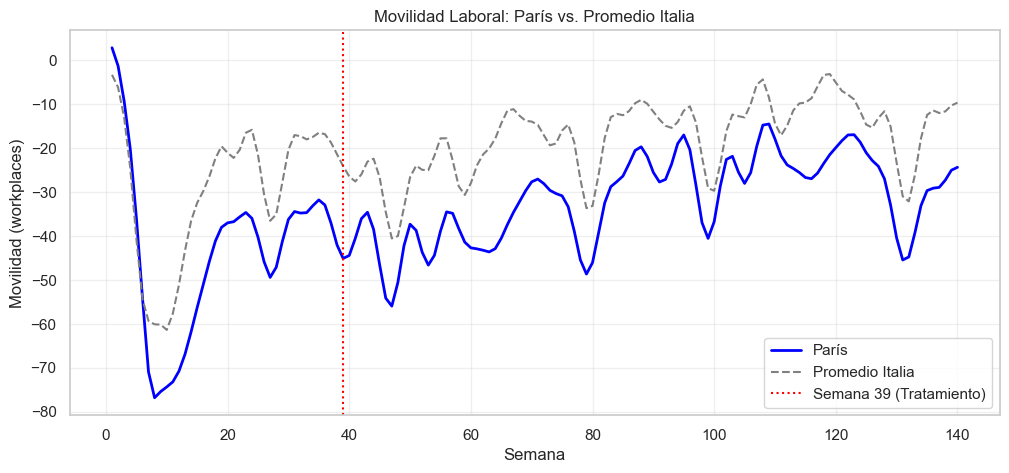

In [14]:
# Justificación de la elección de París y el grupo de control (Italia)
import pandas as pd
import matplotlib.pyplot as plt

datos = pd.read_csv('dataset_prueba.csv')
datos['date'] = pd.to_datetime(datos['date'])
datos.set_index('date', inplace=True, drop=False)

ciudades_it = datos[datos['country'] == 'IT']['NAME'].unique().tolist()
it_data = datos[datos['NAME'].isin(ciudades_it)]
paris_data = datos[datos['NAME'] == 'Paris']

plt.figure(figsize=(12, 5))
plt.plot(paris_data['week'], paris_data['workplaces'], label='París', color='blue', linewidth=2)
plt.plot(it_data.groupby('week')['workplaces'].mean().index, 
         it_data.groupby('week')['workplaces'].mean().values, 
         label='Promedio Italia', color='gray', linestyle='--')
plt.axvline(x=39, color='red', linestyle=':', label='Semana 39 (Tratamiento)')
plt.title('Movilidad Laboral: París vs. Promedio Italia')
plt.xlabel('Semana')
plt.ylabel('Movilidad (workplaces)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Configuración del Dataprep
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth

municipios_control = datos[datos['country'] == 'IT']['NAME'].unique().tolist()

dataprep = Dataprep(
    foo=datos,
    predictors=[
        'Population',
        'agriculture',
        'industry',
        'construction',
        'age_dependency',
        'old_age_dependency',
        'young_age_dependency',
        'sex_ratio',
        'unemp',
        'f_unemp',
    ],
    predictors_op='mean',
    time_predictors_prior=range(1, 39),
    special_predictors=[
        ('daily_cases', range(1, 39), 'mean'),
    ],
    dependent='workplaces',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier='Paris',
    controls_identifier=municipios_control,
    time_optimize_ssr=range(1, 39),
)

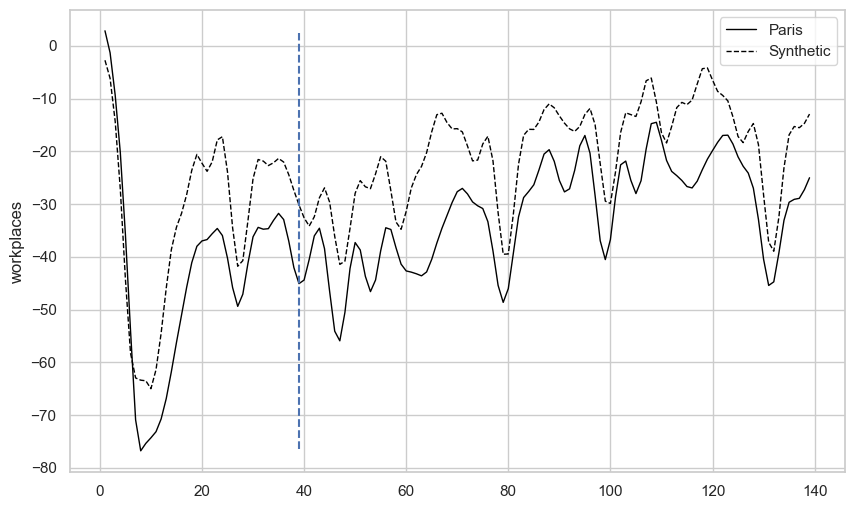

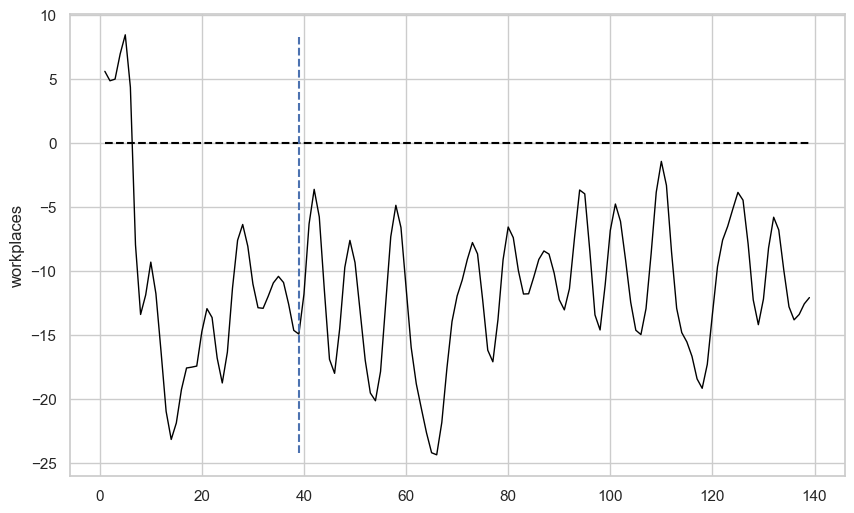

,treated,synthetic,sample mean
Population,10274.884,3095.382,977.653
agriculture,0.001,0.013,0.013
industry,0.114,0.171,0.158
construction,0.039,0.069,0.071
age_dependency,0.668,0.658,0.702
old_age_dependency,0.420,0.330,0.296
young_age_dependency,0.248,0.328,0.406
sex_ratio,107.650,107.034,109.677
unemp,12.000,17.249,13.357
f_unemp,0.118,0.150,0.118


Torino     0.000
Milano     0.322
Venezia    0.000
Verona     0.000
Padova     0.000
Genova     0.000
Bologna    0.000
Firenze    0.000
Roma       0.155
Napoli     0.523
Bari       0.000
Palermo    0.000
Catania    0.000
Messina    0.000
Name: weights, dtype: float64


In [16]:
# Modelo 1: PenalizedSynth (lambda = 0.001)
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.001)

pen.path_plot(time_period=range(1, 140), treatment_time=39)
pen.gaps_plot(time_period=range(1, 140), treatment_time=39)
display(pen.summary())
print(pen.weights())

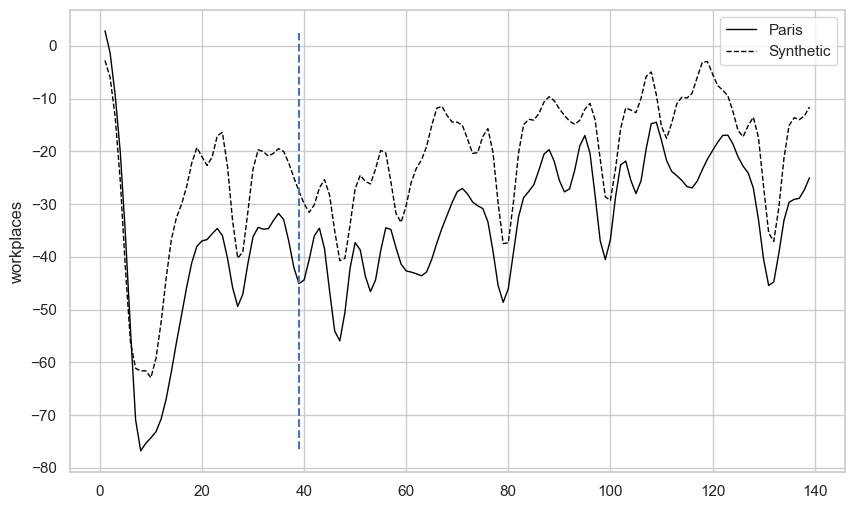

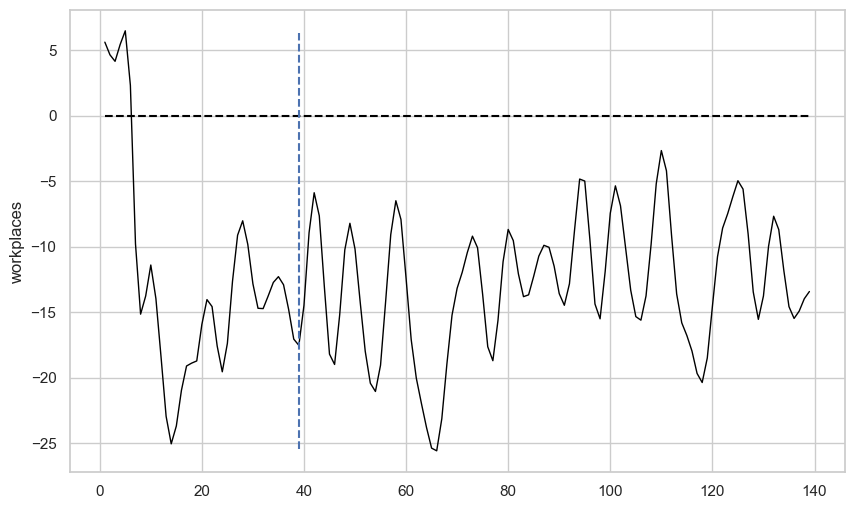

,V,treated,synthetic,sample mean
Population,0.027,10274.884,2279.841,977.653
agriculture,0.134,0.001,0.013,0.013
industry,0.076,0.114,0.159,0.158
construction,0.072,0.039,0.065,0.071
age_dependency,0.248,0.668,0.667,0.702
old_age_dependency,0.007,0.420,0.325,0.296
young_age_dependency,0.139,0.248,0.342,0.406
sex_ratio,0.116,107.650,107.845,109.677
unemp,0.064,12.000,17.704,13.357
f_unemp,0.068,0.118,0.154,0.118


Torino     0.000
Milano     0.118
Venezia    0.000
Verona     0.000
Padova     0.250
Genova     0.000
Bologna    0.000
Firenze    0.000
Roma       0.077
Napoli     0.555
Bari       0.000
Palermo    0.000
Catania    0.000
Messina    0.000
Name: weights, dtype: float64


In [17]:
# Modelo 2: Synth estándar
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="SLSQP", optim_initial="equal", optim_options={"ftol": 1e-3, "maxiter": 100}) # Optimizado para mayor velocidad

synth.path_plot(time_period=range(1, 140), treatment_time=39)
synth.gaps_plot(time_period=range(1, 140), treatment_time=39)
display(synth.summary())
print(synth.weights())

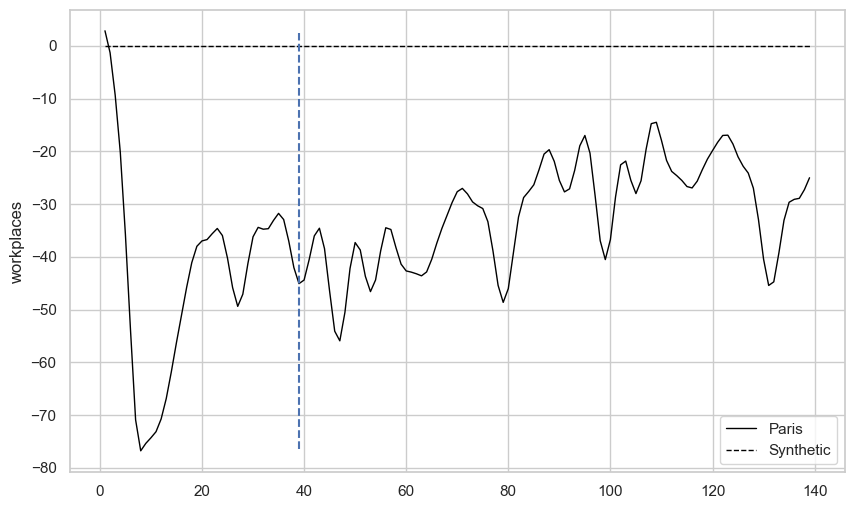

,treated,synthetic,sample mean
Population,10274.884,0.0,977.653
agriculture,0.001,0.0,0.013
industry,0.114,0.0,0.158
construction,0.039,0.0,0.071
age_dependency,0.668,0.0,0.702
old_age_dependency,0.420,0.0,0.296
young_age_dependency,0.248,0.0,0.406
sex_ratio,107.650,0.0,109.677
unemp,12.000,0.0,13.357
f_unemp,0.118,0.0,0.118


Torino    NaN
Milano    NaN
Venezia   NaN
Verona    NaN
Padova    NaN
Genova    NaN
Bologna   NaN
Firenze   NaN
Roma      NaN
Napoli    NaN
Bari      NaN
Palermo   NaN
Catania   NaN
Messina   NaN
Name: weights, dtype: float64


In [18]:
# Modelo 3: AugSynth (Sintético Aumentado)
augsynth = AugSynth()
try:
    augsynth.fit(dataprep=dataprep, lambda_=0.1)
except Exception as e:
    print('AugSynth falló por inestabilidad numérica:', e)

augsynth.path_plot(time_period=range(1, 140), treatment_time=39)
display(augsynth.summary())
print(augsynth.weights())